<a href="https://colab.research.google.com/github/Teixeiras7/Linguagens-de-Programa-o/blob/main/Exercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercício Prático: Análise Visual de Vendas com Pandas e Matplotlib
Objetivo: Ler um conjunto de dados, realizar manipulações básicas com Pandas e criar visualizações claras usando Matplotlib para responder a perguntas de negócios.
Bloco 1: Preparação do Ambiente e Dados
Copie e cole o código abaixo na primeira célula do Google Colab para criar o dataset de treino:


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Criação de um dataset fictício de vendas
np.random.seed(42)
datas = pd.date_range(start="2024-01-01", end="2024-06-30", freq="D")
produtos = ["Notebook", "Smartphone", "Fone de Ouvido", "Monitor"]

dados = {
    "Data": np.random.choice(datas, size=300),
    "Produto": np.random.choice(produtos, size=300, p=[0.2, 0.4, 0.25, 0.15]),
    "Quantidade": np.random.randint(1, 6, size=300),
    "Preco_Unitario": 0
}

df = pd.DataFrame(dados)

# Atribuindo preços de acordo com o produto
precos = {"Notebook": 3500, "Smartphone": 2000, "Fone de Ouvido": 150, "Monitor": 1200}
df["Preco_Unitario"] = df["Produto"].map(precos)

print("Dataset criado com sucesso! Primeiras linhas:")
df.head()

Dataset criado com sucesso! Primeiras linhas:


,Data,Produto,Quantidade,Preco_Unitario
0,2024-04-12,Monitor,3,1200
1,2024-06-28,Smartphone,1,2000
2,2024-04-02,Monitor,5,1200
3,2024-01-15,Fone de Ouvido,4,150
4,2024-04-16,Fone de Ouvido,1,150


Bloco 2: Enunciado das Tarefas para os Alunos
Sua missão: Como analista de dados da empresa, responda aos 3 desafios abaixo escrevendo o código necessário e gerando os gráficos no Colab.


# **Faturamento por Produto **

In [18]:
df['Faturamento_Total'] = df['Quantidade'] * df['Preco_Unitario']
print("Coluna 'Faturamento_Total' criada. Primeiras linhas com a nova coluna:")
display(df.head())

Coluna 'Faturamento_Total' criada. Primeiras linhas com a nova coluna:


,Data,Produto,Quantidade,Preco_Unitario,Faturamento_Total
0,2024-04-12,Monitor,3,1200,3600
1,2024-06-28,Smartphone,1,2000,2000
2,2024-04-02,Monitor,5,1200,6000
3,2024-01-15,Fone de Ouvido,4,150,600
4,2024-04-16,Fone de Ouvido,1,150,150


In [28]:
faturamento_por_produto = df.groupby('Produto')['Faturamento_Total'].sum().reset_index()
print("Faturamento total por produto:")
display(faturamento_por_produto)

Faturamento total por produto:


,Produto,Faturamento_Total
0,Fone de Ouvido,30150
1,Monitor,213600
2,Notebook,686000
3,Smartphone,626000


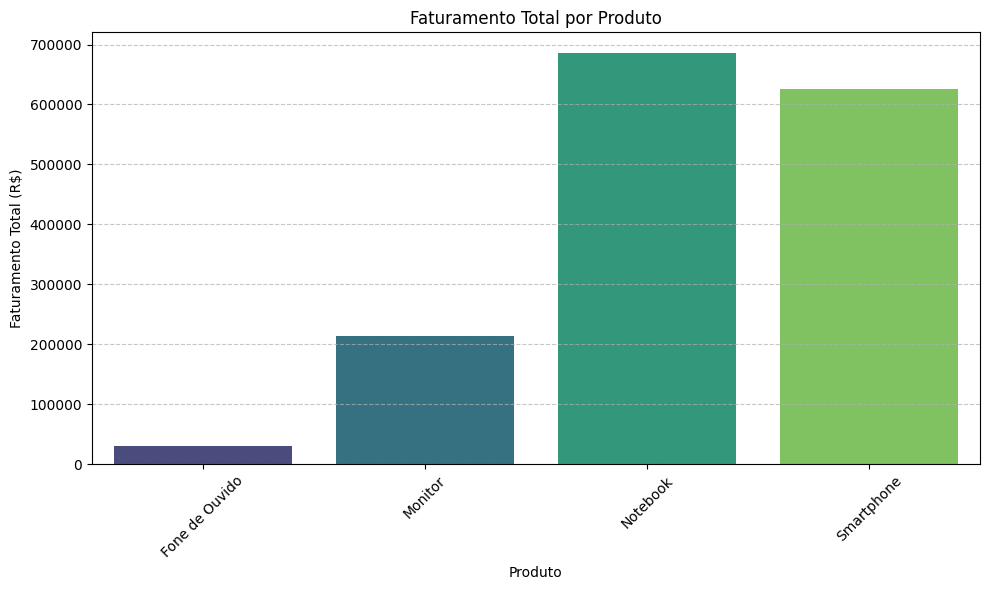

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Produto', y='Faturamento_Total', data=faturamento_por_produto, palette='viridis', hue='Produto', legend=False)
plt.title('Faturamento Total por Produto')
plt.xlabel('Produto')
plt.ylabel('Faturamento Total (R$)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Evolução das Vendas ao Longo do Tempo**

In [21]:
df['Mes'] = df['Data'].dt.to_period('M')
print("Coluna 'Mes' criada. Primeiras linhas com a nova coluna:")
display(df.head())

Coluna 'Mes' criada. Primeiras linhas com a nova coluna:


,Data,Produto,Quantidade,Preco_Unitario,Faturamento_Total,Mes
0,2024-04-12,Monitor,3,1200,3600,2024-04
1,2024-06-28,Smartphone,1,2000,2000,2024-06
2,2024-04-02,Monitor,5,1200,6000,2024-04
3,2024-01-15,Fone de Ouvido,4,150,600,2024-01
4,2024-04-16,Fone de Ouvido,1,150,150,2024-04


In [24]:
faturamento_por_mes = df.groupby('Mes')['Faturamento_Total'].sum().reset_index()
print("Faturamento total por mês:")
display(faturamento_por_mes)


Faturamento total por mês:


,Mes,Faturamento_Total
0,2024-01,210300
1,2024-02,235950
2,2024-03,278450
3,2024-04,247650
4,2024-05,379650
5,2024-06,203750


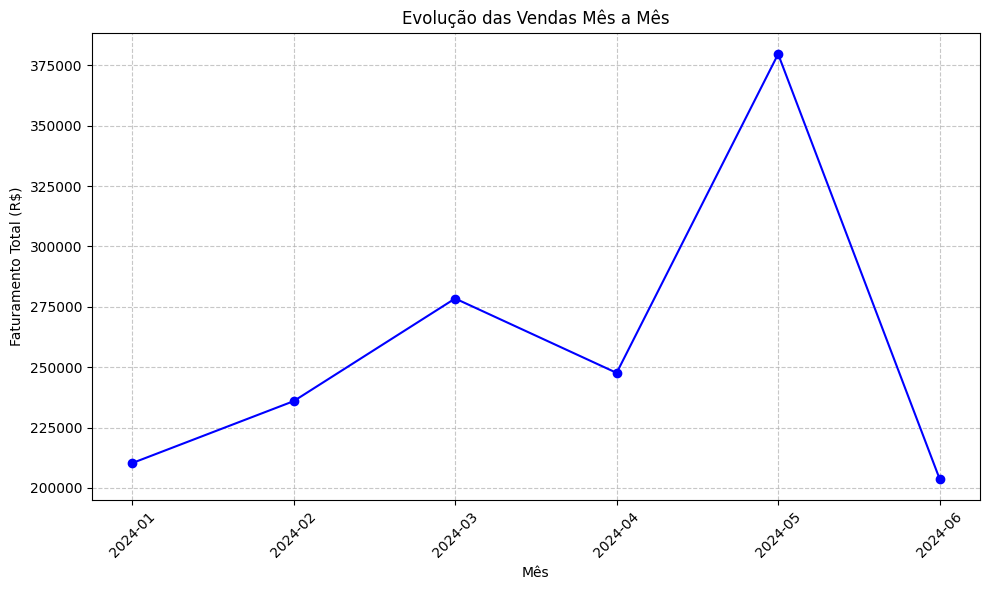

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(faturamento_por_mes['Mes'].astype(str), faturamento_por_mes['Faturamento_Total'], marker='o', linestyle='-', color='blue')
plt.title('Evolução das Vendas Mês a Mês')
plt.xlabel('Mês')
plt.ylabel('Faturamento Total (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Distribuição da Quantidade Vendida**

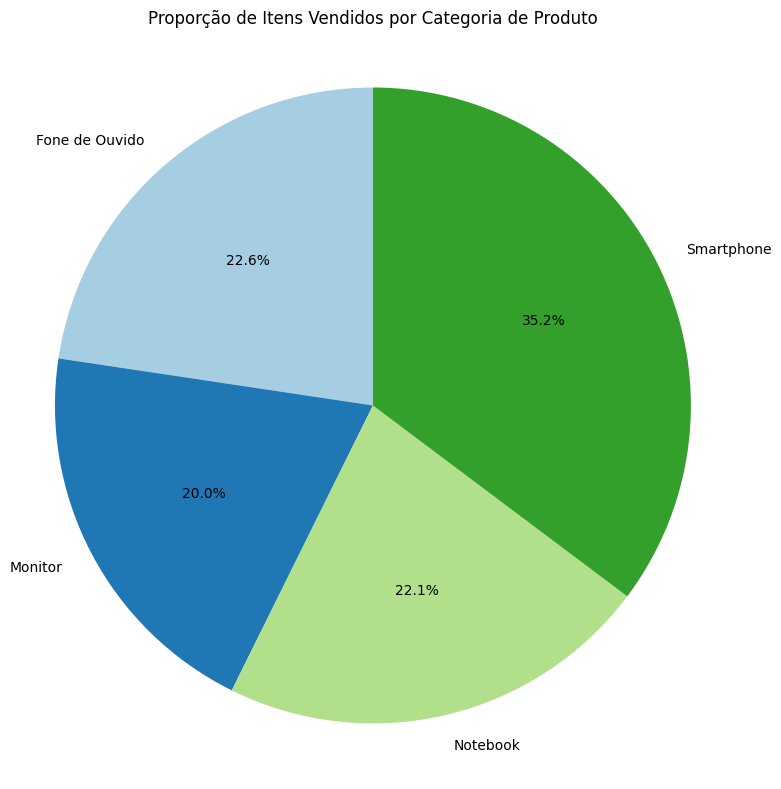

In [23]:
quantidade_por_produto = df.groupby('Produto')['Quantidade'].sum()

plt.figure(figsize=(8, 8))
plt.pie(quantidade_por_produto, labels=quantidade_por_produto.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Proporção de Itens Vendidos por Categoria de Produto')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()